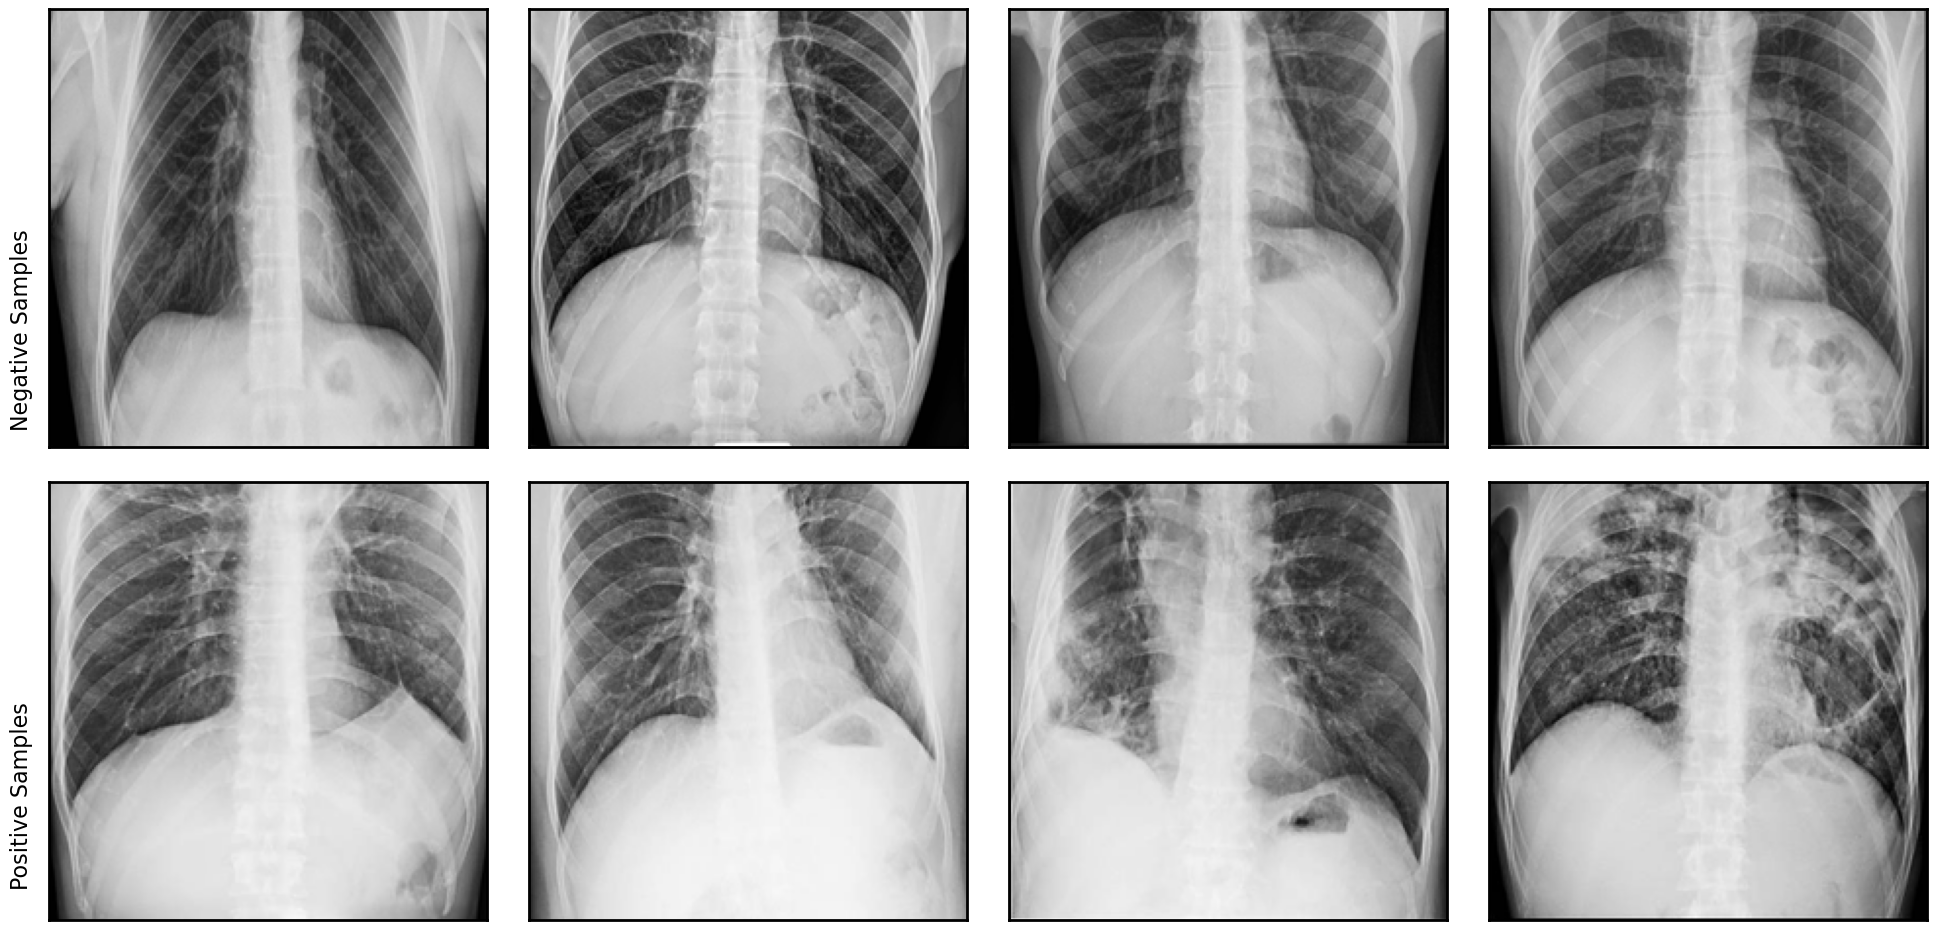

In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os

# --- 1. CONFIGURATION: SET YOUR IMAGE PATHS AND TARGET SIZE ---
# All images will be resized to this dimension for a uniform grid.
TARGET_SIZE = (224, 224)

negative_image_paths = [
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img20.png",
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img28.png",
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img109.png",
    r"d:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img214.png",
]

positive_image_paths = [
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img497.png",
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img527.png",
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img541.png",
    r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI\img565.png",
]


# --- 2. PLOTTING THE 2x4 GRID ---

all_paths = [negative_image_paths, positive_image_paths]
row_labels = ['Negative Samples', 'Positive Samples']

# Create a figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Iterate through the rows (0 for negative, 1 for positive) and columns
for i, row_paths in enumerate(all_paths):
    for j, img_path in enumerate(row_paths):
        ax = axes[i, j]
        
        try:
            # Open the image using the path provided
            img = Image.open(img_path).convert('RGB')
            
            # NEW: Resize the image to the fixed TARGET_SIZE for uniformity
            # Image.Resampling.LANCZOS is a high-quality filter for resizing
            img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
            
            ax.imshow(img)
            
        except FileNotFoundError:
            # If the file is not found, display a placeholder with an error message
            print(f"Warning: File not found at '{img_path}'. Displaying a placeholder.")
            placeholder = Image.new('RGB', TARGET_SIZE, color='lightgray')
            draw = ImageDraw.Draw(placeholder)
            draw.text((50, 100), "Image Not Found", fill='red')
            ax.imshow(placeholder)
            
        # REMOVED: Column titles are no longer needed.
        
        # NEW: Remove axis ticks but add a black outline around the image
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2) # You can adjust the thickness of the outline here

    # Set the row labels on the left side of the plot, rotated vertically
    axes[i, 0].set_ylabel(row_labels[i], rotation='vertical', fontsize=16, labelpad=20, ha='right', va='center')


# Adjust the layout to ensure everything fits well and display the plot
plt.tight_layout(pad=3.0)

# Save the figure as a high-resolution PDF
plt.savefig('image_grid.pdf', dpi=300, bbox_inches='tight')

plt.show()

Successfully loaded and prepared DataFrame for visualization.
Generating publication-quality dataset visualizations...


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17048\3970992697.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.map(class_labels), y=class_counts.values, ax=ax1,


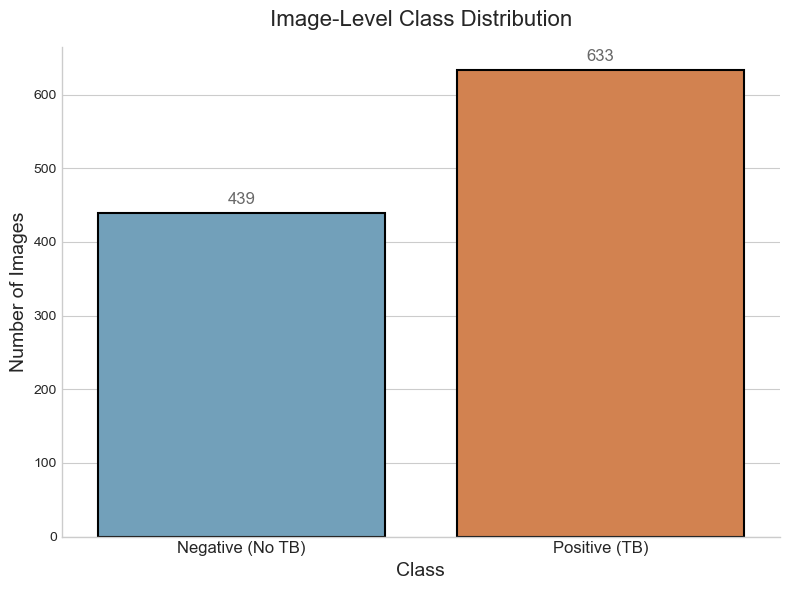

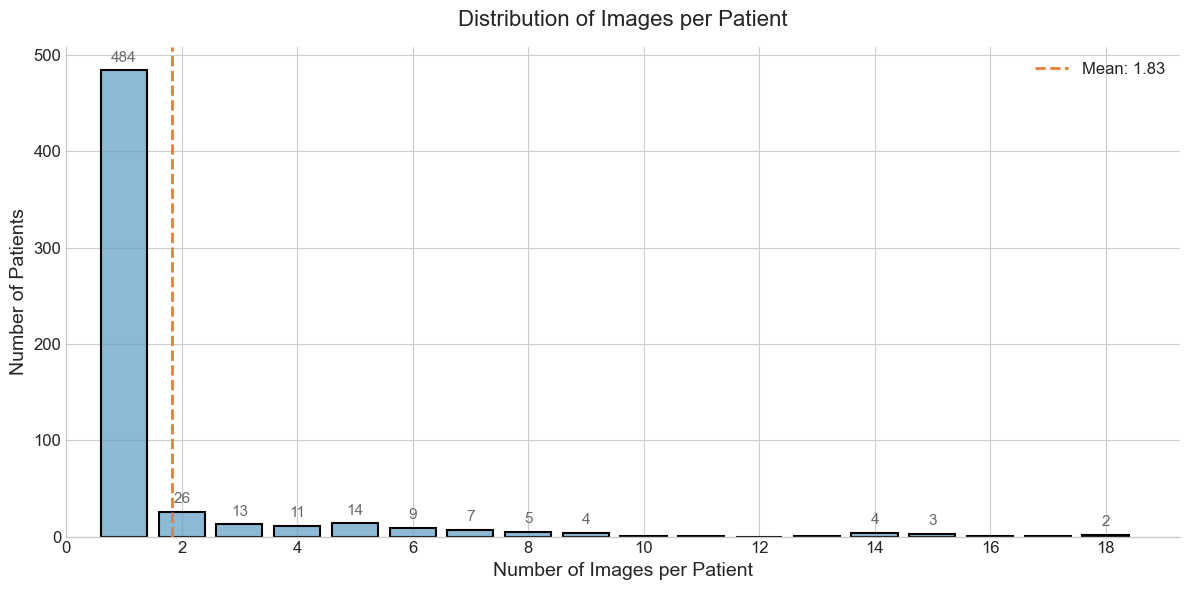

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import os

# --- 1. DATA LOADING AND PREPARATION (Unchanged) ---
# This section loads the CSV and creates the 'all_xray_df' DataFrame needed for the plots.

csv_path = r"D:\iniciacao_cientifica\iniciacao-cientifica\data\Data_Entry_Undergrad_Final.csv"
try:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"The file was not found at the specified path: {csv_path}")
    all_xray_df = pd.read_csv(csv_path)
    if 'Finding Labels' not in all_xray_df.columns or 'Patient ID' not in all_xray_df.columns:
        raise KeyError("The DataFrame is missing 'Finding Labels' or 'Patient ID' columns.")
    mapping_dict = {'TB': 1, 'No Findings': 0}
    all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)
    all_xray_df.dropna(subset=['is_tb'], inplace=True)
    all_xray_df['is_tb'] = all_xray_df['is_tb'].astype(int)
    print("Successfully loaded and prepared DataFrame for visualization.")
except (FileNotFoundError, KeyError) as e:
    print(f"Error: {e}")
    all_xray_df = pd.DataFrame({'is_tb': [], 'Patient ID': []})


# --- 2. PLOTTING SECTION (Revised with outlines) ---

if not all_xray_df.empty:
    print("Generating publication-quality dataset visualizations...")

    # Apply a clean, academic style for all subsequent plots
    plt.style.use('seaborn-v0_8-whitegrid')

    # --- Graph 1: Class Distribution Bar Chart ---
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    
    class_counts = all_xray_df['is_tb'].value_counts()
    class_labels = {0: 'Negative (No TB)', 1: 'Positive (TB)'}
    custom_palette = {'Negative (No TB)': '#66a3c6', 'Positive (TB)': '#e87d3a'}
    
    sns.barplot(x=class_counts.index.map(class_labels), y=class_counts.values, ax=ax1, 
                palette=custom_palette, order=['Negative (No TB)', 'Positive (TB)'],
                edgecolor='black',  # NEW: Add black outline to bars
                linewidth=1.5)      # NEW: Set outline thickness

    ax1.set_title('Image-Level Class Distribution', fontsize=16, pad=15)
    ax1.set_ylabel('Number of Images', fontsize=14)
    ax1.set_xlabel('Class', fontsize=14)
    ax1.tick_params(axis='x', labelsize=12)

    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12, color='dimgray')
    
    sns.despine(fig=fig1)
    plt.tight_layout()
    plt.savefig('class_distribution.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Graph 2: Distribution of Images per Patient ---
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    
    patient_image_counts = all_xray_df['Patient ID'].value_counts()
    sns.histplot(data=patient_image_counts, ax=ax2, discrete=True, color='#66a3c6', shrink=0.8,
                 edgecolor='black',  # NEW: Add consistent outline
                 linewidth=1.5)      # NEW: Set consistent thickness

    ax2.set_title('Distribution of Images per Patient', fontsize=16, pad=15)
    ax2.set_ylabel('Number of Patients', fontsize=14)
    ax2.set_xlabel('Number of Images per Patient', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)

    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.set_xlim(left=0)

    for p in ax2.patches:
        height = int(p.get_height())
        if height > 1:
            ax2.annotate(f'{height}', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11, color='dimgray')

    mean_images = patient_image_counts.mean()
    ax2.axvline(mean_images, color='#e87d3a', linestyle='--', linewidth=2, label=f'Mean: {mean_images:.2f}')
    ax2.legend(fontsize=12)
    
    sns.despine(fig=fig2)
    plt.tight_layout()
    plt.savefig('patient_distribution.pdf', dpi=300, bbox_inches='tight')
    plt.show()